# Análisis: Departamento de Marketing y Estrategia Comercial

**Los códigos son para responder la pregunta de negocio:**
- ¿Cuál es el precio medio de los alojamientos por tipos de alojamientos en cada ciudad?

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Cargar la base de datos limpios

ruta = os.path.join('..', 'Data', 'TouristAccommodationClean19012026.csv')
df = pd.read_csv(ruta)

**Crear un heatmap que muestra los precios medio por tipo de alojamiento en cada ciudad**

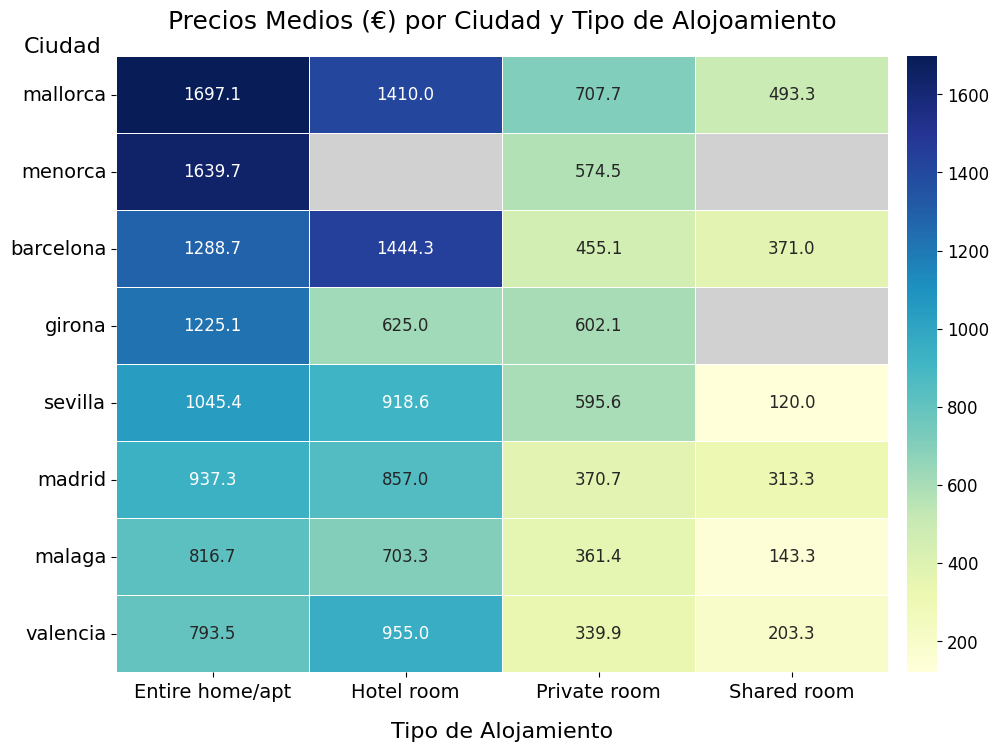

In [6]:
# 1. Matriz de precios medios
precios_matrix = df.pivot_table(index='city', columns='room_type', values='price', aggfunc='mean').sort_values("Entire home/apt", ascending = False)
 
# 2. Matriz de etiquetas personalizada (Números o N/A)
labels = precios_matrix.map(lambda v: f"{v:.1f}" if not np.isnan(v) else "N/A")
 
# 3. Configuración del gráfico
plt.figure(figsize=(12, 8))
plt.gca().set_facecolor('#d1d1d1') # Fondo gris para los N/A
 
# 4. Heatmap con escala de azules
g = sns.heatmap(
    precios_matrix, 
    annot=labels,
    annot_kws={"fontsize": 12},
    fmt="", 
    cmap="YlGnBu",      # Escala de azules/verdes
    linewidths=.5,
    mask=precios_matrix.isnull(), 
    cbar_kws={"pad": 0.02}
)

plt.title('Precios Medios (€) por Ciudad y Tipo de Alojoamiento', pad=20, fontsize=18)
plt.xlabel('Tipo de Alojamiento', fontsize = 16, labelpad = 15)
plt.ylabel('Ciudad', fontsize = 16, rotation = 0, ha = 'left', y = 1, labelpad=-10)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14, rotation = 0)

# configurar tamaño de textos en el colorbar
cbar = g.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
plt.show()